# KNN - самостоятельная реализация алгоритма

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris, load_diabetes
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

from algorithms.KNN import KNN

In [3]:
# Загружаем датасет iris
X1, y1 = load_iris(return_X_y=True, as_frame=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1.values, y1.values, random_state=0)
print(X1, y1, sep='\n')
        

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
0      0
1      0
2      0
3      0
4   

In [4]:
# Загружаем датасет diabet
X2, y2 = load_diabetes(return_X_y=True, as_frame=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2.values, y2.values, random_state=0)
print(X2, y2, sep='\n')

          age       sex       bmi  ...        s4        s5        s6
0    0.038076  0.050680  0.061696  ... -0.002592  0.019907 -0.017646
1   -0.001882 -0.044642 -0.051474  ... -0.039493 -0.068332 -0.092204
2    0.085299  0.050680  0.044451  ... -0.002592  0.002861 -0.025930
3   -0.089063 -0.044642 -0.011595  ...  0.034309  0.022688 -0.009362
4    0.005383 -0.044642 -0.036385  ... -0.002592 -0.031988 -0.046641
..        ...       ...       ...  ...       ...       ...       ...
437  0.041708  0.050680  0.019662  ... -0.002592  0.031193  0.007207
438 -0.005515  0.050680 -0.015906  ...  0.034309 -0.018114  0.044485
439  0.041708  0.050680 -0.015906  ... -0.011080 -0.046883  0.015491
440 -0.045472 -0.044642  0.039062  ...  0.026560  0.044529 -0.025930
441 -0.045472 -0.044642 -0.073030  ... -0.039493 -0.004222  0.003064

[442 rows x 10 columns]
0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name

In [5]:
# First Dataset
knn_clf_1 = KNN()
knn_clf_1.fit(X1_train, y1_train)
knn_clf_preds_1 = knn_clf_1.predict(X1_test)

report_1 = classification_report(y1_test, knn_clf_preds_1)
print(report_1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



In [6]:
# Second dataset
knn_clf_2 = KNN(n_neighbors=8, regression=True)
knn_clf_2.fit(X2_train, y2_train)
knn_clf_2_preds = knn_clf_2.predict(X2_test)
mse = mean_squared_error(y2_test, knn_clf_2_preds)
mae = mean_absolute_error(y2_test, knn_clf_2_preds)
rmse = root_mean_squared_error(y2_test, knn_clf_2_preds)
r2 = r2_score(y2_test, knn_clf_2_preds)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 3837.1734234234236
MAE: 48.288288288288285
RMSE: 61.94492249913163
R2: 0.22706411462868414


In [7]:
# Функция для отрисовки графика
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

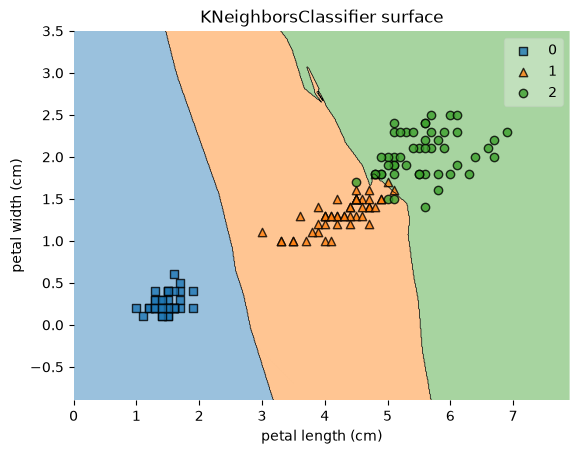

In [8]:
feature_indexes = [2, 3]
title1 = 'KNeighborsClassifier surface'
decision_boundary_plot(X1, y1, X1_train, y1_train, knn_clf_1, feature_indexes, title1)


In [9]:
# Попробуем использовать классификатор KNN из scikit-learn
from sklearn.neighbors import KNeighborsClassifier

scikit_knn = KNeighborsClassifier()

scikit_knn.fit(X1_train, y1_train)
scikit_knn_preds = scikit_knn.predict(X1_test)
scikit_report = classification_report(y1_test, scikit_knn_preds)
print(scikit_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

